In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import statistics

In [2]:
import numpy as np
import pandas as pd
df=pd.read_csv("./GIT/flu_esp_index.csv", sep=",",index_col=0)
df.index = pd.to_datetime(df.index)
df

,INF_ALL,TG,HU,RR,FG
2013-09-29,1.0,216.857143,65.682540,16.206349,29.984127
2013-10-06,1.0,208.269841,68.738095,25.285714,29.206349
2013-10-13,0.0,170.111111,61.190476,1.285714,21.587302
2013-10-20,1.0,185.380952,68.619048,7.460317,25.063492
2013-10-27,0.0,174.761905,73.920635,43.920635,33.761905
...,...,...,...,...,...
2025-01-05,442.0,73.492063,75.174603,11.113228,28.714286
2025-01-12,574.0,108.984127,71.460317,13.174603,43.000000
2025-01-19,622.0,60.761905,58.619048,4.791005,23.555556
2025-01-26,506.0,106.222222,79.920635,43.611111,38.619048


In [3]:
df.corr(method='pearson')

,INF_ALL,TG,HU,RR,FG
INF_ALL,1.000000,-0.495126,0.348469,0.091998,0.106542
TG,-0.495126,1.000000,-0.687060,-0.295821,-0.272616
HU,0.348469,-0.687060,1.000000,0.576649,0.064088
RR,0.091998,-0.295821,0.576649,1.000000,0.382179
FG,0.106542,-0.272616,0.064088,0.382179,1.000000


### Cálculo de la ventana deslizante

In [4]:
def one_step_forecast(df, window):
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]
    for start in range(n-window):
        end = start + window
        x.append(d[start:end])
    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)
    return pd.concat([df_y,df_xs], axis=1).dropna()

In [5]:
df_inf=one_step_forecast(df.iloc[:,0],4) #ventana deslizante de infectados
df_temp=one_step_forecast(df.iloc[:,1],4).iloc[:,1:].rename({'x_1':'x_1_temp','x_2':'x_2_temp','x_3':'x_3_temp','x_4':'x_4_temp'},axis=1)

In [6]:
df=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_inf.iloc[:,2],df_temp.iloc[:,1],df_inf.iloc[:,3],df_temp.iloc[:,2],df_inf.iloc[:,4],df_temp.iloc[:,3]],axis=1)
df

,y,x_1,x_1_temp,x_2,x_2_temp,x_3,x_3_temp,x_4,x_4_temp
fecha,,,,,,,,,
2013-09-29,0.0,1.0,216.857143,1.0,208.269841,0.0,170.111111,1.0,185.380952
2013-10-06,1.0,1.0,208.269841,0.0,170.111111,1.0,185.380952,0.0,174.761905
2013-10-13,0.0,0.0,170.111111,1.0,185.380952,0.0,174.761905,1.0,137.460317
2013-10-20,3.0,1.0,185.380952,0.0,174.761905,1.0,137.460317,0.0,151.301587
2013-10-27,6.0,0.0,174.761905,1.0,137.460317,0.0,151.301587,3.0,111.539683
...,...,...,...,...,...,...,...,...,...
2024-12-08,442.0,101.0,112.682540,221.0,66.063492,117.0,92.333333,164.0,87.984127
2024-12-15,574.0,221.0,66.063492,117.0,92.333333,164.0,87.984127,442.0,73.492063
2024-12-22,622.0,117.0,92.333333,164.0,87.984127,442.0,73.492063,574.0,108.984127


### Normalización y separación en test y train 

In [7]:
def split_data(df,test_split=0.1):
    n=int(len(df)*test_split)
    train,test=df[:-n],df[-n:]
    return train, test

In [8]:
train,test=split_data(df)

In [9]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm=pd.DataFrame(norm.fit_transform(train),index=train.index,columns=train.columns)
test_norm=pd.DataFrame(norm.transform(test),index=test.index,columns=test.columns)

In [10]:
xtrainN=train_norm.iloc[:,1:]
xtestN=test_norm.iloc[:,1:]
ytrainN=train_norm.iloc[:,0]
ytestN=test_norm.iloc[:,0]
xtrainN.shape

(462, 8)

### Regresión lineal

In [11]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(xtrainN,ytrainN)
ypred=regr.predict(xtestN)
Y_rl=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_rl['ypred']=pd.DataFrame(ypred,index=ytestN.index)
Y_rl

,ytest,ypred
fecha,,
2024-01-21,0.058704,0.060731
2024-01-28,0.032389,0.044019
2024-02-04,0.044534,0.027481
2024-02-11,0.032389,0.076606
2024-02-18,0.030364,0.048408
2024-02-25,0.018219,0.047833
2024-03-03,0.014170,0.016043
2024-03-10,0.014170,0.038440
2024-03-17,0.012146,0.038771


In [12]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(ytestN, ypred)
r2=r2_score(ytestN, ypred)
print(mse)
print(r2)

0.009794054842056296
0.896276103643736


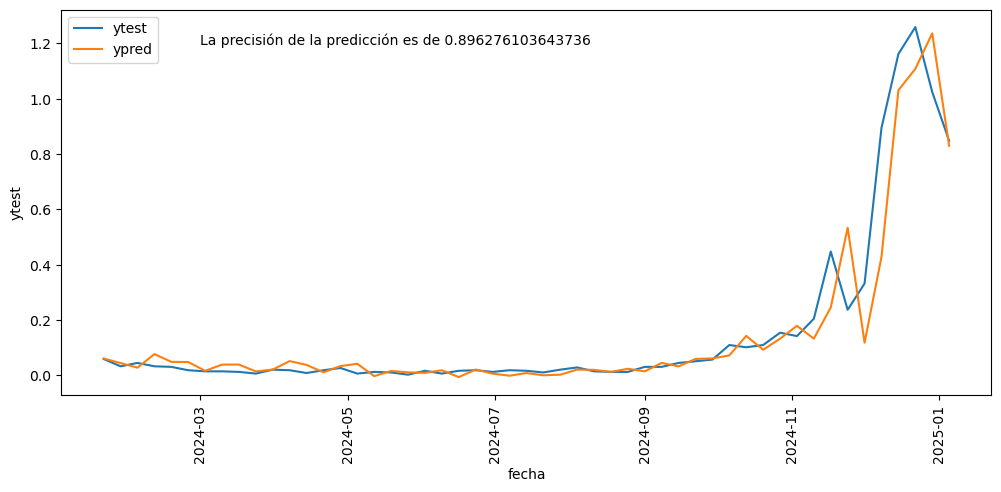

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ytest,label='ytest')
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2024, 3, 1), 0.95*max(Y_rl.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rl.ytest, Y_rl.ypred)), fontsize=10)
plt.show()

### KNNeighbors

In [14]:
from sklearn.neighbors import KNeighborsRegressor
v=[]
for k in range(1,15):
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(xtrainN,ytrainN)
    ypred=knn.predict(xtestN.values.astype(np.float32))
    v.append(r2_score(ytestN, ypred))

v

[0.7968131388708581,
 0.7929324870649112,
 0.8031954682818303,
 0.7979327458467763,
 0.8111749117138387,
 0.7815520261891474,
 0.7814112590617374,
 0.7925046038269884,
 0.7660506317307972,
 0.7725404000036842,
 0.7514833313469825,
 0.7422253081945744,
 0.7354003498361896,
 0.7263243096319287]

In [15]:
knn=KNeighborsRegressor(n_neighbors=3)
knn.fit(xtrainN,ytrainN)

KNeighborsRegressor(n_neighbors=3)

In [16]:
ypred_knn=knn.predict(xtestN.values.astype(np.float32))
Y_knn=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_knn['ypred']=pd.DataFrame(ypred_knn,index=ytestN.index)
Y_knn

,ytest,ypred
fecha,,
2024-01-21,0.058704,0.037787
2024-01-28,0.032389,0.039811
2024-02-04,0.044534,0.014170
2024-02-11,0.032389,0.037787
2024-02-18,0.030364,0.023617
2024-02-25,0.018219,0.023617
2024-03-03,0.014170,0.002024
2024-03-10,0.014170,0.030364
2024-03-17,0.012146,0.058704


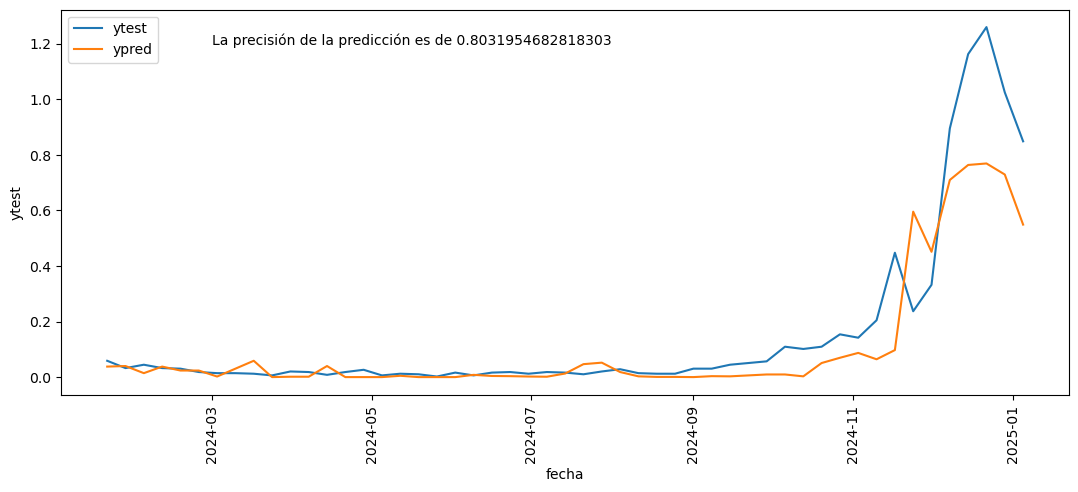

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_knn,x=Y_knn.index,y=Y_knn.ytest,label='ytest')
sns.lineplot(data=Y_knn,x=Y_knn.index,y=Y_knn.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2024, 3, 1), 0.95*max(Y_knn.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_knn.ytest, Y_knn.ypred)), fontsize=10)
plt.show()

### Random Forest 

In [18]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [19]:
rf=RandomForestRegressor(random_state=0)
rf.fit(xtrainN,ytrainN)

RandomForestRegressor(random_state=0)

In [20]:
ypred=rf.predict(xtestN.values.astype(np.float32))
Y_rf=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_rf['ypred']=pd.DataFrame(ypred,index=ytestN.index)
Y_rf

,ytest,ypred
fecha,,
2024-01-21,0.058704,0.059939
2024-01-28,0.032389,0.050830
2024-02-04,0.044534,0.031437
2024-02-11,0.032389,0.031275
2024-02-18,0.030364,0.037510
2024-02-25,0.018219,0.054433
2024-03-03,0.014170,0.025972
2024-03-10,0.014170,0.012045
2024-03-17,0.012146,0.008968


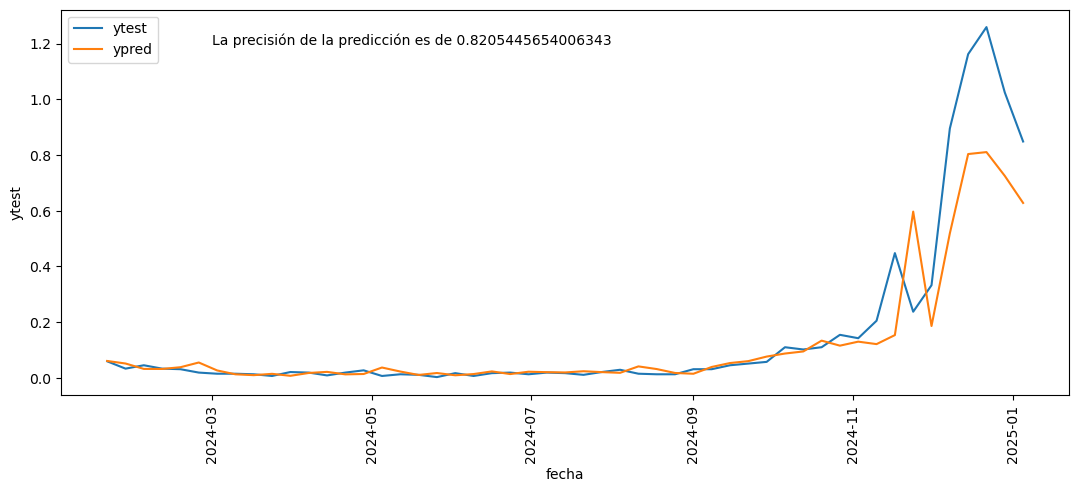

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_rf,x=Y_rf.index,y=Y_rf.ytest,label='ytest')
sns.lineplot(data=Y_rf,x=Y_rf.index,y=Y_rf.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2024, 3, 1), 0.95*max(Y_rf.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rf.ytest, Y_rf.ypred)), fontsize=10)
plt.show()

### Gradient Boosting

In [22]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor(random_state=0)
gbr.fit(xtrainN,ytrainN)
ypred_gbr=gbr.predict(xtestN.values.astype(np.float32))
Y_gbr=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_gbr['ypred']=pd.DataFrame(ypred_gbr,index=ytestN.index)
Y_gbr

,ytest,ypred
fecha,,
2024-01-21,0.058704,0.049660
2024-01-28,0.032389,0.044002
2024-02-04,0.044534,0.041290
2024-02-11,0.032389,0.040173
2024-02-18,0.030364,0.070944
2024-02-25,0.018219,0.038856
2024-03-03,0.014170,0.024739
2024-03-10,0.014170,0.018181
2024-03-17,0.012146,0.010695


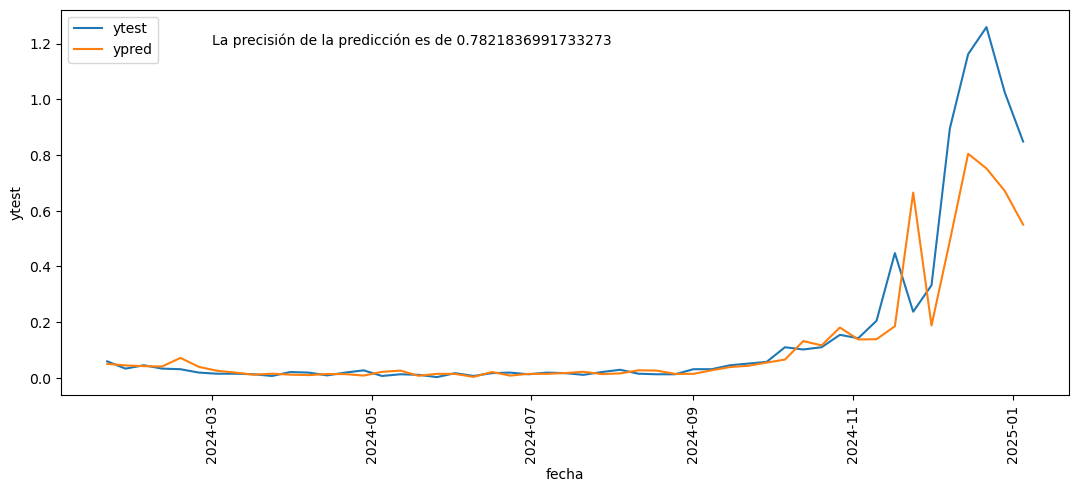

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_gbr,x=Y_gbr.index,y=Y_gbr.ytest,label='ytest')
sns.lineplot(data=Y_gbr,x=Y_gbr.index,y=Y_gbr.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2024, 3, 1), 0.95*max(Y_gbr.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_gbr.ytest, Y_gbr.ypred)), fontsize=10)
plt.show()

### Validación

In [24]:
xtrainN,xvalN=split_data(xtrainN)
ytrainN,yvalN=split_data(ytrainN)

### RNA

In [25]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dropout, Dense
from tensorflow.keras.optimizers import Adam

In [26]:
Y_rna=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rna=Sequential()
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna.add(Dropout(0.1))
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna.add(Dropout(0.1))
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna.add(Dropout(0.1))
    rna.add(Dense(1))
    rna.compile(optimizer=Adam(learning_rate=0.003),loss='mean_squared_error')
    rna.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna=rna.predict(xtestN)
    Y_rna['ypred_'+str(i)]=pd.DataFrame(ypred_rna,index=ytestN.index)
    
Y_rna

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0563 - val_loss: 0.0395
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0447 - val_loss: 0.0283
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0298 - val_loss: 0.0188
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0204 - val_loss: 0.0147
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0166 - val_loss: 0.0108
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0137 - val_loss: 0.0092
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0108 - val_loss: 0.0072
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0090 - val_loss: 0.0065
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 - val_loss: 0.0067
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - val_loss: 0.0060
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0108 - val_loss: 0.0061
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - val_loss: 0.0032
Epoch 138/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0049 - val_loss: 0.0035
Epoch 139/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 140/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - val_loss: 0.0034
Epoch 141/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - val_loss: 0.0032
Epoch 142/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - val_loss: 0.0046
Epoch 143/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - val_loss: 0.0034
Epoch 144/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - val_loss: 0.0032
Epoch 145/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - val_loss: 0.0033
Epoch 146/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 - val_loss: 0.0046
Epoch 147/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 148/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039 - val_loss: 0.0031
Epoch 272/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 273/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 274/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 275/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 - val_loss: 0.0032
Epoch 276/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037 - val_loss: 0.0031
Epoch 277/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055 - val_loss: 0.0038
Epoch 278/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - val_loss: 0.0053
Epoch 279/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0053 - val_loss: 0.0031
Epoch 280/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 281/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - val_loss: 0.0030
Epoch 282/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 406/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 407/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - val_loss: 0.0036
Epoch 408/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - val_loss: 0.0033
Epoch 409/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_loss: 0.0036
Epoch 410/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - val_loss: 0.0034
Epoch 411/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 412/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 413/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025 - val_loss: 0.0034
Epoch 414/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0033
Epoch 415/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - val_loss: 0.0032
Epoch 416/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0037
Epoch 40/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - val_loss: 0.0037
Epoch 41/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 42/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 43/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - val_loss: 0.0036
Epoch 44/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056 - val_loss: 0.0036
Epoch 45/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - val_loss: 0.0043
Epoch 46/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0053 - val_loss: 0.0037
Epoch 47/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056 - val_loss: 0.0040
Epoch 48/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046 - val_loss: 0.0036
Epoch 49/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044 - val_loss: 0.0036
Epoch 50/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 

...

Epoch 35/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0059 - val_loss: 0.0047
Epoch 36/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063 - val_loss: 0.0045
Epoch 37/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - val_loss: 0.0045
Epoch 38/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - val_loss: 0.0046
Epoch 39/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0060 - val_loss: 0.0047
Epoch 40/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061 - val_loss: 0.0047
Epoch 41/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 42/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0064 - val_loss: 0.0045
Epoch 43/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0048
Epoch 44/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0053 - val_loss: 0.0044
Epoch 45/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - val_loss: 0.0043
Epoch 46/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - val_loss: 0.0038
Epoch 171/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 172/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 173/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - val_loss: 0.0039
Epoch 174/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 175/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0054 - val_loss: 0.0041
Epoch 176/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0038 - val_loss: 0.0039
Epoch 177/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 - val_loss: 0.0038
Epoch 178/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 - val_loss: 0.0042
Epoch 179/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044 - val_loss: 0.0041
Epoch 180/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - val_loss: 0.0044
Epoch 181/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - val_loss: 0.0040
Epoch 305/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - val_loss: 0.0039
Epoch 306/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 307/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - val_loss: 0.0043
Epoch 308/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - val_loss: 0.0040
Epoch 309/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - val_loss: 0.0045
Epoch 310/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - val_loss: 0.0046
Epoch 311/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0043
Epoch 312/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 313/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0042
Epoch 314/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0040
Epoch 315/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - val_loss: 0.0047
Epoch 439/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - val_loss: 0.0039
Epoch 440/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0040 - val_loss: 0.0045
Epoch 441/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 442/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - val_loss: 0.0043
Epoch 443/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_loss: 0.0041
Epoch 444/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - val_loss: 0.0040
Epoch 445/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 0.0041
Epoch 446/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - val_loss: 0.0038
Epoch 447/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 448/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027 - val_loss: 0.0041
Epoch 449/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
fecha,,,,,
2024-01-21,0.058704,0.090731,0.035671,0.085386,0.058130
2024-01-28,0.032389,0.054449,0.038145,0.026725,0.030664
2024-02-04,0.044534,0.029555,0.021546,0.007114,0.007588
2024-02-11,0.032389,0.066337,0.020343,0.017044,0.007086
2024-02-18,0.030364,0.043305,0.024302,0.004940,0.015267
2024-02-25,0.018219,0.028571,0.019753,0.001423,0.006058
2024-03-03,0.014170,0.006053,0.003993,-0.000311,0.003857
2024-03-10,0.014170,0.005687,0.003993,-0.000235,0.021308
2024-03-17,0.012146,0.006260,0.003993,-0.000216,0.012010


In [27]:
v=[]
for i in range(4):
    v.append(r2_score(Y_rna.iloc[:,0], Y_rna.iloc[:,i+1]))

v

[0.9312631893568172,
 0.9361483984584688,
 0.9076568765344045,
 0.9389423323216177]

### RNN

In [28]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import SimpleRNN, Dropout, Dense

In [29]:
Y_rnn=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rnn1=Sequential()
    rnn1.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn1.add(Dropout(0.1))
    rnn1.add(Dense(1))
    rnn1.compile(optimizer=Adam(learning_rate=0.003),loss='mse')
    rnn1.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn=rnn1.predict(xtestN)
    Y_rnn['ypred_'+str(i)]=pd.DataFrame(ypred_rnn,index=ytestN.index)
    
Y_rnn

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0623 - val_loss: 0.0227
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0300 - val_loss: 0.0102
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0151 - val_loss: 0.0083
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0112 - val_loss: 0.0069
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0099 - val_loss: 0.0055
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0079 - val_loss: 0.0052
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0070 - val_loss: 0.0050
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061 - val_loss: 0.0049
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053 - val_loss: 0.0047
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - val_loss: 0.0049
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 - val_loss: 0.0046
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022 - val_loss: 0.0034
Epoch 138/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 139/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0034
Epoch 140/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0035
Epoch 141/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015 - val_loss: 0.0028
Epoch 142/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0026
Epoch 143/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0038
Epoch 144/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 145/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0025
Epoch 146/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 147/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0030
Epoch 148/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 272/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 273/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015 - val_loss: 0.0032
Epoch 274/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - val_loss: 0.0035
Epoch 275/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 276/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0038
Epoch 277/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015 - val_loss: 0.0025
Epoch 278/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0038
Epoch 279/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0029
Epoch 280/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014 - val_loss: 0.0025
Epoch 281/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 282/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 0.0028
Epoch 406/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - val_loss: 0.0029
Epoch 407/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 0.0022
Epoch 408/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.8794e-04 - val_loss: 0.0030
Epoch 409/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0031
Epoch 410/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0030
Epoch 411/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0025
Epoch 412/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 413/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 414/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - val_loss: 0.0033
Epoch 415/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 416/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 0.0037
Epoch 40/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044 - val_loss: 0.0036
Epoch 41/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - val_loss: 0.0040
Epoch 42/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 - val_loss: 0.0036
Epoch 43/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 44/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0049 - val_loss: 0.0042
Epoch 45/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - val_loss: 0.0040
Epoch 46/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - val_loss: 0.0042
Epoch 47/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0040
Epoch 48/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0044
Epoch 49/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - val_loss: 0.0040
Epoch 50/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - val_loss: 0.0057
Epoch 480/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - val_loss: 0.0054
Epoch 481/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0044
Epoch 482/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.3257e-04 - val_loss: 0.0054
Epoch 483/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.4460e-04 - val_loss: 0.0063
Epoch 484/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - val_loss: 0.0067
Epoch 485/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - val_loss: 0.0047
Epoch 486/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - val_loss: 0.0035
Epoch 487/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014 - val_loss: 0.0046
Epoch 488/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.1341e-04 - val_loss: 0.0041
Epoch 489/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.2592e-04 - val_loss: 0.0054
Epoch 490/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022 - val_loss: 0.0038
Epoch 115/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - val_loss: 0.0032
Epoch 116/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0031
Epoch 117/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0036
Epoch 118/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025 - val_loss: 0.0033
Epoch 119/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 120/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0036
Epoch 121/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0036
Epoch 122/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 0.0036
Epoch 123/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0030
Epoch 124/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - val_loss: 0.0029
Epoch 125/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - val_loss: 0.0042
Epoch 249/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - val_loss: 0.0023
Epoch 250/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 251/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0031
Epoch 252/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0034
Epoch 253/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 254/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020 - val_loss: 0.0041
Epoch 255/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 256/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 257/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022 - val_loss: 0.0035
Epoch 258/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - val_loss: 0.0025
Epoch 259/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0023
Epoch 383/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 384/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0031
Epoch 385/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0040
Epoch 386/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 0.0038
Epoch 387/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - val_loss: 0.0029
Epoch 388/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0026
Epoch 389/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - val_loss: 0.0038
Epoch 390/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 391/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - val_loss: 0.0042
Epoch 392/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0028
Epoch 393/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
fecha,,,,,
2024-01-21,0.058704,0.035435,0.070595,0.075496,0.029084
2024-01-28,0.032389,0.061397,0.055853,0.032273,0.045402
2024-02-04,0.044534,0.033881,0.019095,0.056700,0.048028
2024-02-11,0.032389,0.033411,0.046675,0.075157,0.033017
2024-02-18,0.030364,0.025224,0.053674,0.040820,0.026967
2024-02-25,0.018219,0.025791,0.025896,0.038634,0.139977
2024-03-03,0.014170,0.013448,0.004366,0.023895,0.066934
2024-03-10,0.014170,-0.001788,0.016542,0.003408,0.054198
2024-03-17,0.012146,-0.002357,0.014456,0.017938,0.009552


In [30]:
w=[]
for i in range(4):
    w.append(r2_score(Y_rnn.iloc[:,0], Y_rnn.iloc[:,i+1]))

w

[0.8649799840946091,
 0.9510540006531809,
 0.8815240971031849,
 0.8985912474888785]

In [45]:
#import matplotlib.pyplot as plt
#import seaborn as sns
#plt.figure(figsize=(13,5))
#sns.lineplot(data=Y_rnn,x=Y_rnn.index,y=Y_rnn.ytest,label='ytest')
#sns.lineplot(data=Y_rnn,x=Y_rnn.index,y=Y_rnn.ypred_0,label='ypred_0')
#sns.lineplot(data=Y_rnn,x=Y_rnn.index,y=Y_rnn.ypred_1,label='ypred_1')
#sns.lineplot(data=Y_rnn,x=Y_rnn.index,y=Y_rnn.ypred_2,label='ypred_2')
#sns.lineplot(data=Y_rnn,x=Y_rnn.index,y=Y_rnn.ypred_3,label='ypred_3')
#plt.legend()
#plt.xticks(rotation=90)
#plt.text(datetime(2024, 3, 1), 0.95*max(Y_rnn.ytest), 'La precisión de la predicción es de '+str(statistics.mean(w)), fontsize=10)
#plt.show()

In [4]:
#XX=pd.concat([Y_rnn.ypred_1,xtestN],axis=1)
#XY=pd.concat([ytestN,xtestN],axis=1)
#desnormXX=pd.DataFrame(norm.inverse_transform(XX),index=test.index,columns=test.columns).rename({'y':'ypred_1'},axis=1)
#desnormXY=pd.DataFrame(norm.inverse_transform(XY),index=test.index,columns=test.columns)
#d=pd.concat([desnormXX.iloc[:,0],desnormXY.iloc[:,0]],axis=1)
#r2_score(d.iloc[:,1],d.iloc[:,0])

### LSTM

In [31]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dense, LSTM, Dropout

In [32]:
Y_lstm=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    lstm = Sequential()
    lstm.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm.add(Dropout(0.1))
    lstm.add(Dense(1))
    lstm.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    lstm.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm=lstm.predict(xtestN)
    Y_lstm['ypred_'+str(i)]=pd.DataFrame(ypred_lstm,index=ytestN.index)

Y_lstm

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0571 - val_loss: 0.0397
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0455 - val_loss: 0.0371
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0432 - val_loss: 0.0335
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0376 - val_loss: 0.0270
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0305 - val_loss: 0.0208
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0251 - val_loss: 0.0193
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0204 - val_loss: 0.0168
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0179 - val_loss: 0.0128
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0185 - val_loss: 0.0128
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0145 - val_loss: 0.0125
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0150 - val_loss: 0.0123
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 138/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - val_loss: 0.0052
Epoch 139/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 0.0037
Epoch 140/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - val_loss: 0.0041
Epoch 141/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 142/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 0.0036
Epoch 143/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022 - val_loss: 0.0032
Epoch 144/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - val_loss: 0.0037
Epoch 145/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025 - val_loss: 0.0039
Epoch 146/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0042
Epoch 147/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022 - val_loss: 0.0031
Epoch 148/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 0.0039
Epoch 272/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - val_loss: 0.0034
Epoch 273/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - val_loss: 0.0031
Epoch 274/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - val_loss: 0.0036
Epoch 275/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015 - val_loss: 0.0033
Epoch 276/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - val_loss: 0.0033
Epoch 277/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 278/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0031
Epoch 279/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 280/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - val_loss: 0.0039
Epoch 281/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0035
Epoch 282/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - val_loss: 0.0045
Epoch 406/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 0.0042
Epoch 407/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - val_loss: 0.0041
Epoch 408/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - val_loss: 0.0036
Epoch 409/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0017 - val_loss: 0.0040
Epoch 410/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - val_loss: 0.0036
Epoch 411/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 0.0048
Epoch 412/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016 - val_loss: 0.0040
Epoch 413/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - val_loss: 0.0040
Epoch 414/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 - val_loss: 0.0038
Epoch 415/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0040
Epoch 416/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079 - val_loss: 0.0053
Epoch 39/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0073 - val_loss: 0.0054
Epoch 40/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071 - val_loss: 0.0051
Epoch 41/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - val_loss: 0.0052
Epoch 42/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0052
Epoch 43/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0074 - val_loss: 0.0053
Epoch 44/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0077 - val_loss: 0.0050
Epoch 45/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 - val_loss: 0.0051
Epoch 46/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0070 - val_loss: 0.0049
Epoch 47/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 - val_loss: 0.0049
Epoch 48/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0089 - val_loss: 0.0048
Epoch 49/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0059 

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - val_loss: 0.0048
Epoch 115/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0043
Epoch 116/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - val_loss: 0.0056
Epoch 117/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0057
Epoch 118/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 0.0047
Epoch 119/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0044
Epoch 120/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - val_loss: 0.0055
Epoch 121/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 0.0057
Epoch 122/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 0.0041
Epoch 123/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 0.0046
Epoch 124/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - val_loss: 0.0051
Epoch 125/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0079
Epoch 249/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 0.0086
Epoch 250/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 0.0066
Epoch 251/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - val_loss: 0.0080
Epoch 252/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 0.0079
Epoch 253/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0066
Epoch 254/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020 - val_loss: 0.0082
Epoch 255/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 0.0072
Epoch 256/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 0.0067
Epoch 257/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 0.0074
Epoch 258/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 0.0082
Epoch 259/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 0.0082
Epoch 383/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 0.0088
Epoch 384/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - val_loss: 0.0079
Epoch 385/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0090
Epoch 386/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 0.0073
Epoch 387/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - val_loss: 0.0080
Epoch 388/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 0.0094
Epoch 389/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0074
Epoch 390/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.6728e-04 - val_loss: 0.0085
Epoch 391/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014 - val_loss: 0.0091
Epoch 392/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0080
Epoch 393/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.8364e-04 - val_loss: 0.0086
Epoch 450/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0100
Epoch 451/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0613e-04 - val_loss: 0.0094
Epoch 452/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0081
Epoch 453/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0075
Epoch 454/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.7605e-04 - val_loss: 0.0089
Epoch 455/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5695e-04 - val_loss: 0.0084
Epoch 456/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 0.0089
Epoch 457/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015 - val_loss: 0.0082
Epoch 458/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0080
Epoch 459/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0086
Epoch 460/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
fecha,,,,,
2024-01-21,0.058704,0.065542,0.055170,0.042243,0.057335
2024-01-28,0.032389,0.055450,0.044151,0.034559,0.065025
2024-02-04,0.044534,0.048875,0.031930,0.006773,0.020460
2024-02-11,0.032389,0.071069,0.063645,0.038821,0.043323
2024-02-18,0.030364,0.047764,0.062334,0.023008,0.027582
2024-02-25,0.018219,0.045893,0.067774,0.028934,0.046970
2024-03-03,0.014170,0.025721,0.034164,0.005910,0.020231
2024-03-10,0.014170,0.027882,0.030659,0.010897,0.027471
2024-03-17,0.012146,0.013283,0.011884,0.008237,0.013448


In [33]:
u=[]
for i in range(4):
    u.append(r2_score(Y_lstm.iloc[:,0], Y_lstm.iloc[:,i+1]))

u

[0.882401820466963, 0.8904710617738759, 0.8594250107564679, 0.9297549720355768]

### GRU

In [34]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dense, GRU, Dropout

In [35]:
Y_gru=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    gru = Sequential()
    gru.add(GRU(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru.add(Dropout(0.1))
    gru.add(Dense(1))
    gru.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    gru.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_gru=gru.predict(xtestN)
    Y_gru['ypred_'+str(i)]=pd.DataFrame(ypred_gru,index=ytestN.index)

Y_gru

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0597 - val_loss: 0.0391
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0444 - val_loss: 0.0368
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0436 - val_loss: 0.0331
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0395 - val_loss: 0.0293
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0358 - val_loss: 0.0228
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0260 - val_loss: 0.0137
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0167 - val_loss: 0.0097
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0151 - val_loss: 0.0100
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0155 - val_loss: 0.0105
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0128 - val_loss: 0.0085
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0135 - val_loss: 0.0082
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - val_loss: 0.0041
Epoch 138/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 139/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024 - val_loss: 0.0037
Epoch 140/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0036
Epoch 141/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - val_loss: 0.0041
Epoch 142/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0021 - val_loss: 0.0037
Epoch 143/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - val_loss: 0.0040
Epoch 144/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - val_loss: 0.0039
Epoch 145/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 0.0050
Epoch 146/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - val_loss: 0.0034
Epoch 147/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0021 - val_loss: 0.0037
Epoch 148/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 0.0029
Epoch 272/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 273/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 274/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - val_loss: 0.0027
Epoch 275/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - val_loss: 0.0026
Epoch 276/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - val_loss: 0.0040
Epoch 277/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 0.0029
Epoch 278/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 0.0041
Epoch 279/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 0.0031
Epoch 280/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 0.0029
Epoch 281/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 0.0036
Epoch 282/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 0.0022
Epoch 406/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 0.0022
Epoch 407/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0028
Epoch 408/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 0.0029
Epoch 409/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 410/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 411/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 412/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 0.0028
Epoch 413/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.5432e-04 - val_loss: 0.0038
Epoch 414/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 - val_loss: 0.0024
Epoch 415/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 0.0032
Epoch 416/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034 - val_loss: 0.0040
Epoch 40/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0046 - val_loss: 0.0039
Epoch 41/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 42/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 43/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 44/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 45/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 46/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 47/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - val_loss: 0.0035
Epoch 48/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 49/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 50/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - val_loss: 0.0037
Epoch 44/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - val_loss: 0.0042
Epoch 45/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 46/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - val_loss: 0.0036
Epoch 47/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 48/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - val_loss: 0.0038
Epoch 49/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - val_loss: 0.0036
Epoch 50/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0030 - val_loss: 0.0036
Epoch 51/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 52/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037 - val_loss: 0.0036
Epoch 53/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - val_loss: 0.0044
Epoch 54/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 0.0033
Epoch 179/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 0.0039
Epoch 180/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - val_loss: 0.0032
Epoch 181/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0035
Epoch 182/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0038
Epoch 183/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 184/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - val_loss: 0.0034
Epoch 185/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - val_loss: 0.0027
Epoch 186/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0028
Epoch 187/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0033
Epoch 188/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018 - val_loss: 0.0029
Epoch 189/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - lo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 0.0030
Epoch 313/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3072e-04 - val_loss: 0.0021
Epoch 314/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.1744e-04 - val_loss: 0.0029
Epoch 315/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 316/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 317/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0026
Epoch 318/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.6823e-04 - val_loss: 0.0030
Epoch 319/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0030
Epoch 320/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0037
Epoch 321/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0031
Epoch 322/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0029
Epoch 323/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5

Epoch 379/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.4869e-04 - val_loss: 0.0034
Epoch 380/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.6315e-04 - val_loss: 0.0029
Epoch 381/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.0443e-04 - val_loss: 0.0031
Epoch 382/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.6798e-04 - val_loss: 0.0029
Epoch 383/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 0.0028
Epoch 384/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 0.0030
Epoch 385/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.9181e-04 - val_loss: 0.0036
Epoch 386/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7927e-04 - val_loss: 0.0034
Epoch 387/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 0.0033
Epoch 388/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.9913e-04 - val_loss: 0.0028
Epoch 389/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.0417e-04 - val_loss: 0.0043
Epoch 390/5

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
fecha,,,,,
2024-01-21,0.058704,0.054480,0.056917,0.057999,0.064840
2024-01-28,0.032389,0.029698,0.041684,0.040602,0.036640
2024-02-04,0.044534,0.011086,0.026431,0.017295,0.023432
2024-02-11,0.032389,0.050289,0.044077,0.049621,0.084279
2024-02-18,0.030364,0.023968,0.037302,0.042623,0.045618
2024-02-25,0.018219,0.028542,0.028510,0.026154,0.029713
2024-03-03,0.014170,0.009495,0.012732,0.010373,0.007667
2024-03-10,0.014170,0.009116,0.020325,0.023442,0.012879
2024-03-17,0.012146,-0.010313,0.024191,0.016291,0.016073


In [36]:
y=[]
for i in range(4):
    y.append(r2_score(Y_gru.iloc[:,0], Y_gru.iloc[:,i+1]))

y

[0.9091625821503874, 0.925294346628786, 0.9327451358603366, 0.8899273685767566]

### 3-LSTM

In [37]:
Y_rnn_lstm=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rnn_lstm3 = Sequential()
    rnn_lstm3.add(LSTM(64, input_shape=(len(xtrainN.columns), 1),return_sequences=True))
    rnn_lstm3.add(Dropout(0.1))
    rnn_lstm3.add(LSTM(64,return_sequences=True))
    rnn_lstm3.add(Dropout(0.1))
    rnn_lstm3.add(LSTM(64))
    rnn_lstm3.add(Dense(1))
    rnn_lstm3.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    rnn_lstm3.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn_lstm=rnn_lstm3.predict(xtestN)
    Y_rnn_lstm['ypred_'+str(i)]=pd.DataFrame(ypred_rnn_lstm,index=ytestN.index)

Y_rnn_lstm

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0559 - val_loss: 0.0494
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0526 - val_loss: 0.0406
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0476 - val_loss: 0.0410
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0475 - val_loss: 0.0404
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0467 - val_loss: 0.0406
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0465 - val_loss: 0.0403
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0460 - val_loss: 0.0403
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0463 - val_loss: 0.0397
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0449 - val_loss: 0.0393
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0449 - val_loss: 0.0387
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0438 - val_loss: 0.0385
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0018 - val_loss: 0.0032
Epoch 136/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0036
Epoch 137/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0017 - val_loss: 0.0039
Epoch 138/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - val_loss: 0.0041
Epoch 139/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0019 - val_loss: 0.0034
Epoch 140/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - val_loss: 0.0040
Epoch 141/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0020 - val_loss: 0.0037
Epoch 142/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 143/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0018 - val_loss: 0.0036
Epoch 144/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0021 - val_loss: 0.0038
Epoch 145/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0021 - val_loss: 0.0035
Epoch 146/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0482e-04 - val_loss: 0.0040
Epoch 269/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.0426e-04 - val_loss: 0.0036
Epoch 270/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4401e-04 - val_loss: 0.0041
Epoch 271/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.8006e-04 - val_loss: 0.0048
Epoch 272/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.9987e-04 - val_loss: 0.0048
Epoch 273/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7.3625e-04 - val_loss: 0.0035
Epoch 274/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.8966e-04 - val_loss: 0.0046
Epoch 275/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8700e-04 - val_loss: 0.0043
Epoch 276/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.2803e-04 - val_loss: 0.0041
Epoch 277/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.1610e-04 - val_loss: 0.0042
Epoch 278/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4268e-04 - val_loss: 0.0043
Ep

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6.9862e-04 - val_loss: 0.0075
Epoch 399/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.5742e-04 - val_loss: 0.0074
Epoch 400/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.7573e-04 - val_loss: 0.0063
Epoch 401/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.8747e-04 - val_loss: 0.0069
Epoch 402/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.0414e-04 - val_loss: 0.0054
Epoch 403/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.3186e-04 - val_loss: 0.0069
Epoch 404/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.6256e-04 - val_loss: 0.0058
Epoch 405/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.1622e-04 - val_loss: 0.0065
Epoch 406/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.6000e-04 - val_loss: 0.0060
Epoch 407/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7927e-04 - val_loss: 0.0063
Epoch 408/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.4277e-04 - val_loss: 0.0069
Ep

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0163 - val_loss: 0.0130
Epoch 29/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0118 - val_loss: 0.0134
Epoch 30/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0109 - val_loss: 0.0126
Epoch 31/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0106 - val_loss: 0.0145
Epoch 32/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0115 - val_loss: 0.0173
Epoch 33/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0090 - val_loss: 0.0168
Epoch 34/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0111 - val_loss: 0.0122
Epoch 35/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0080 - val_loss: 0.0130
Epoch 36/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0071 - val_loss: 0.0094
Epoch 37/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - val_loss: 0.0081
Epoch 38/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0058 - val_loss: 0.0083
Epoch 39/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - l

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0434 - val_loss: 0.0368
Epoch 17/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0424 - val_loss: 0.0363
Epoch 18/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0415 - val_loss: 0.0350
Epoch 19/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0411 - val_loss: 0.0327
Epoch 20/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0390 - val_loss: 0.0308
Epoch 21/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0361 - val_loss: 0.0279
Epoch 22/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0305 - val_loss: 0.0244
Epoch 23/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0273 - val_loss: 0.0215
Epoch 24/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0244 - val_loss: 0.0197
Epoch 25/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0222 - val_loss: 0.0222
Epoch 26/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0219 - val_loss: 0.0180
Epoch 27/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - l

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0022 - val_loss: 0.0039
Epoch 151/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0022 - val_loss: 0.0039
Epoch 152/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0041
Epoch 153/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - val_loss: 0.0042
Epoch 154/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0019 - val_loss: 0.0043
Epoch 155/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0018 - val_loss: 0.0040
Epoch 156/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0018 - val_loss: 0.0032
Epoch 157/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 0.0045
Epoch 158/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 0.0036
Epoch 159/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0017 - val_loss: 0.0043
Epoch 160/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0017 - val_loss: 0.0034
Epoch 161/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15

Epoch 283/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2437e-04 - val_loss: 0.0044
Epoch 284/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1377e-04 - val_loss: 0.0041
Epoch 285/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.0784e-04 - val_loss: 0.0044
Epoch 286/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.8325e-04 - val_loss: 0.0042
Epoch 287/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0411e-04 - val_loss: 0.0047
Epoch 288/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.2121e-04 - val_loss: 0.0042
Epoch 289/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.9702e-04 - val_loss: 0.0042
Epoch 290/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.1802e-04 - val_loss: 0.0044
Epoch 291/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.3028e-04 - val_loss: 0.0043
Epoch 292/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.6489e-04 - val_loss: 0.0044
Epoch 293/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8225e-04 - val_l

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.6438e-04 - val_loss: 0.0052
Epoch 414/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.0136e-04 - val_loss: 0.0057
Epoch 415/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3423e-04 - val_loss: 0.0054
Epoch 416/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.9283e-04 - val_loss: 0.0057
Epoch 417/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.6303e-04 - val_loss: 0.0055
Epoch 418/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.2445e-04 - val_loss: 0.0059
Epoch 419/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.3565e-04 - val_loss: 0.0067
Epoch 420/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.9423e-04 - val_loss: 0.0057
Epoch 421/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3575e-04 - val_loss: 0.0055
Epoch 422/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.0035e-04 - val_loss: 0.0049
Epoch 423/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0959e-04 - val_loss: 0.0056
Ep

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
fecha,,,,,
2024-01-21,0.058704,0.031647,0.061284,0.031769,0.055338
2024-01-28,0.032389,0.009290,0.021849,0.027830,-0.020570
2024-02-04,0.044534,0.020097,0.019077,0.023500,0.017112
2024-02-11,0.032389,0.060065,0.036763,0.044602,0.049366
2024-02-18,0.030364,0.023068,0.016469,0.032811,0.009152
2024-02-25,0.018219,0.029687,0.034737,0.043608,0.027776
2024-03-03,0.014170,-0.000997,0.012561,0.023873,0.013686
2024-03-10,0.014170,0.004923,0.003865,-0.001545,0.002090
2024-03-17,0.012146,0.003417,0.026272,0.013631,0.016415


In [38]:
z=[]
for i in range(4):
    z.append(r2_score(Y_rnn_lstm.iloc[:,0], Y_rnn_lstm.iloc[:,i+1]))

z

[0.8610135166102576, 0.9098464319273459, 0.8648029052352335, 0.867553692405447]

In [39]:
import statistics
dic={"fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'Regresion lineal':r2_score(Y_rl.ytest, Y_rl.ypred),
    'KNN': r2_score(Y_knn.ytest, Y_knn.ypred),
    'Random Forest':r2_score(Y_rf.ytest, Y_rf.ypred),
    'Gradient Boosting':r2_score(Y_gbr.ytest, Y_gbr.ypred),
    'RNA':statistics.mean(v),
    'RNN':statistics.mean(w),
    'LSTM':statistics.mean(u),
    'GRU':statistics.mean(y),
    'RNN-LSTM':statistics.mean(z),
    'Notas':'Flu ventana deslizante de 4 datos médicos y temp media t-1 t-1 .. t-4 t-4 learning 0.003'}
dic

{'fecha': '2025-04-27 12:41:55',
 'Regresion lineal': 0.896276103643736,
 'KNN': 0.8031954682818303,
 'Random Forest': 0.8205445654006343,
 'Gradient Boosting': 0.7821836991733273,
 'RNA': 0.928502699167827,
 'RNN': 0.8990373323349634,
 'LSTM': 0.8905132162582209,
 'GRU': 0.9142823583040667,
 'RNN-LSTM': 0.875804136544571,
 'Notas': 'Flu ventana deslizante de 4 datos médicos y temp media t-1 t-1 .. t-4 t-4 learning 0.003'}

In [40]:
DF=pd.DataFrame(dic.values(),index=dic.keys())
DF

,0
fecha,2025-04-27 12:41:55
Regresion lineal,0.896276
KNN,0.803195
Random Forest,0.820545
Gradient Boosting,0.782184
RNA,0.928503
RNN,0.899037
LSTM,0.890513
GRU,0.914282
RNN-LSTM,0.875804


In [41]:
#DF.to_excel('ejecuciones.xlsx',index=True)

In [42]:
import os
if os.path.exists('ejecuciones.xlsx'):
    with pd.ExcelWriter('ejecuciones.xlsx', engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
        df_existente = pd.read_excel('ejecuciones.xlsx', sheet_name='Flu',index_col=0)
        df_completo = pd.concat([df_existente, DF], axis=1)
        df_completo.to_excel(writer, sheet_name='Flu')